In [2]:
# Import the tools needed for data handling and machine learning
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load the dataset
df = pd.read_csv('../data/Final_Augmented_dataset_Diseases_and_Symptoms.csv')

# Seperate the output label (diseases) from input features (symptoms)
y = df['diseases']
X = df.drop(columns=['diseases'])

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate model performance on the test set
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Save the trained model and feature list for the frontend pair 
joblib.dump(model, '../models/symptom_checker_model.pkl')
joblib.dump(list(X.columns), '../models/symptom_list.pkl')

print("Success! Model and symptom list saved into models/ folder.")

Model Accuracy: 81.44%



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklea

Classification Report:
                                                           precision    recall  f1-score   support

                               abdominal aortic aneurysm       0.80      1.00      0.89        20
                                        abdominal hernia       0.88      0.93      0.90        81
                                         abscess of nose       0.68      0.90      0.78        58
                                     abscess of the lung       0.86      1.00      0.92         6
                                  abscess of the pharynx       0.79      0.94      0.86        63
                                    acanthosis nigricans       0.75      1.00      0.86         6
                                               acariasis       0.45      1.00      0.62         5
                                               achalasia       0.55      0.90      0.68        20
                                                    acne       0.56      0.79      0.66      

In [3]:
import os 
print(os.listdir('../models'))

['symptom_checker_model.pkl', 'symptom_list.pkl']


In [1]:
import joblib

m = joblib.load('../models/symptom_checker_model.pkl')
joblib.dump(m, '../models/symptom_checker_model.pkl', compress=3)
print("Model compressed successfully!")

Model compressed successfully!


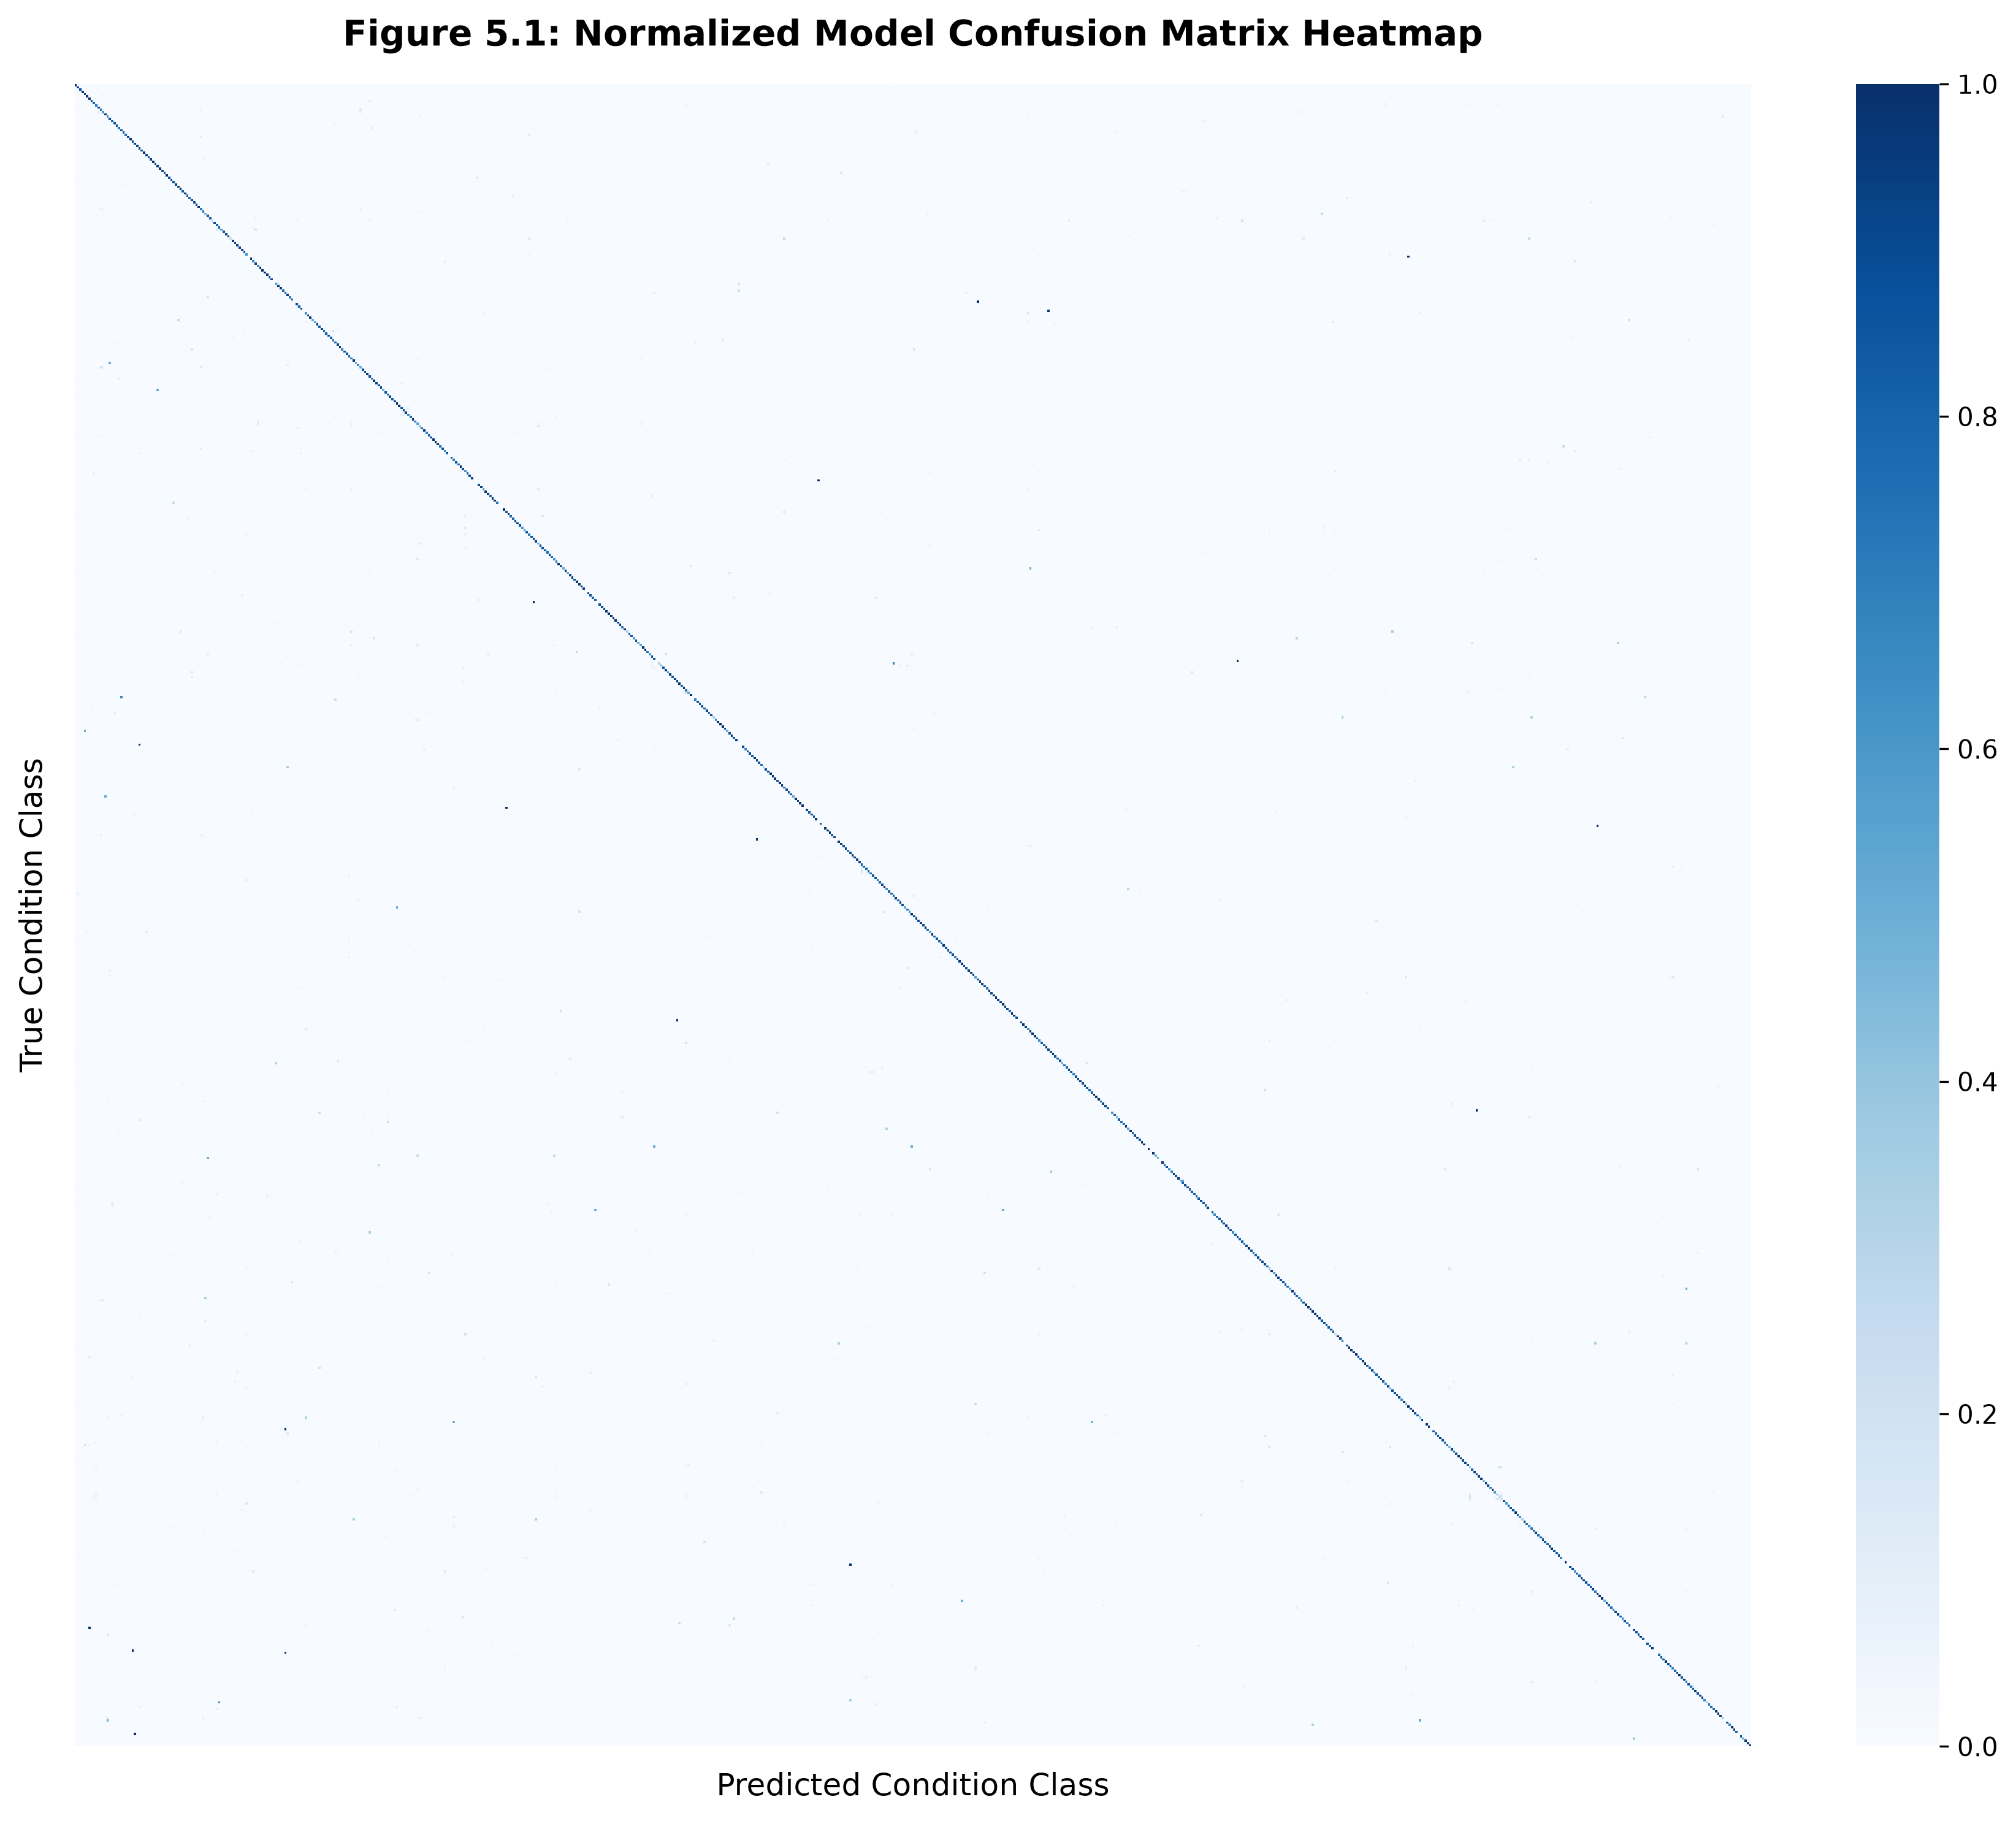

In [2]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# 1. Load dataset & model artifact directly
df = pd.read_csv('../data/Final_Augmented_dataset_Diseases_and_Symptoms.csv')
X = df.drop(columns=['diseases'])
y = df['diseases']

# Re-split to recreate exact test set
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load saved trained model
model = joblib.load('../models/symptom_checker_model.pkl')

# 2. Compute predictions & confusion matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, normalize='true')

# 3. Render high-resolution heatmap
plt.figure(figsize=(12, 10), dpi=300)
sns.heatmap(
    cm, 
    cmap='Blues', 
    cbar=True, 
    xticklabels=False, 
    yticklabels=False
)

# 4. Academic formatting (APA style)
plt.title('Figure 5.1: Normalized Model Confusion Matrix Heatmap', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Predicted Condition Class', fontsize=12, labelpad=10)
plt.ylabel('True Condition Class', fontsize=12, labelpad=10)
plt.tight_layout()

# 5. Save and display image
plt.savefig('../docs/figure_5_1_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklea

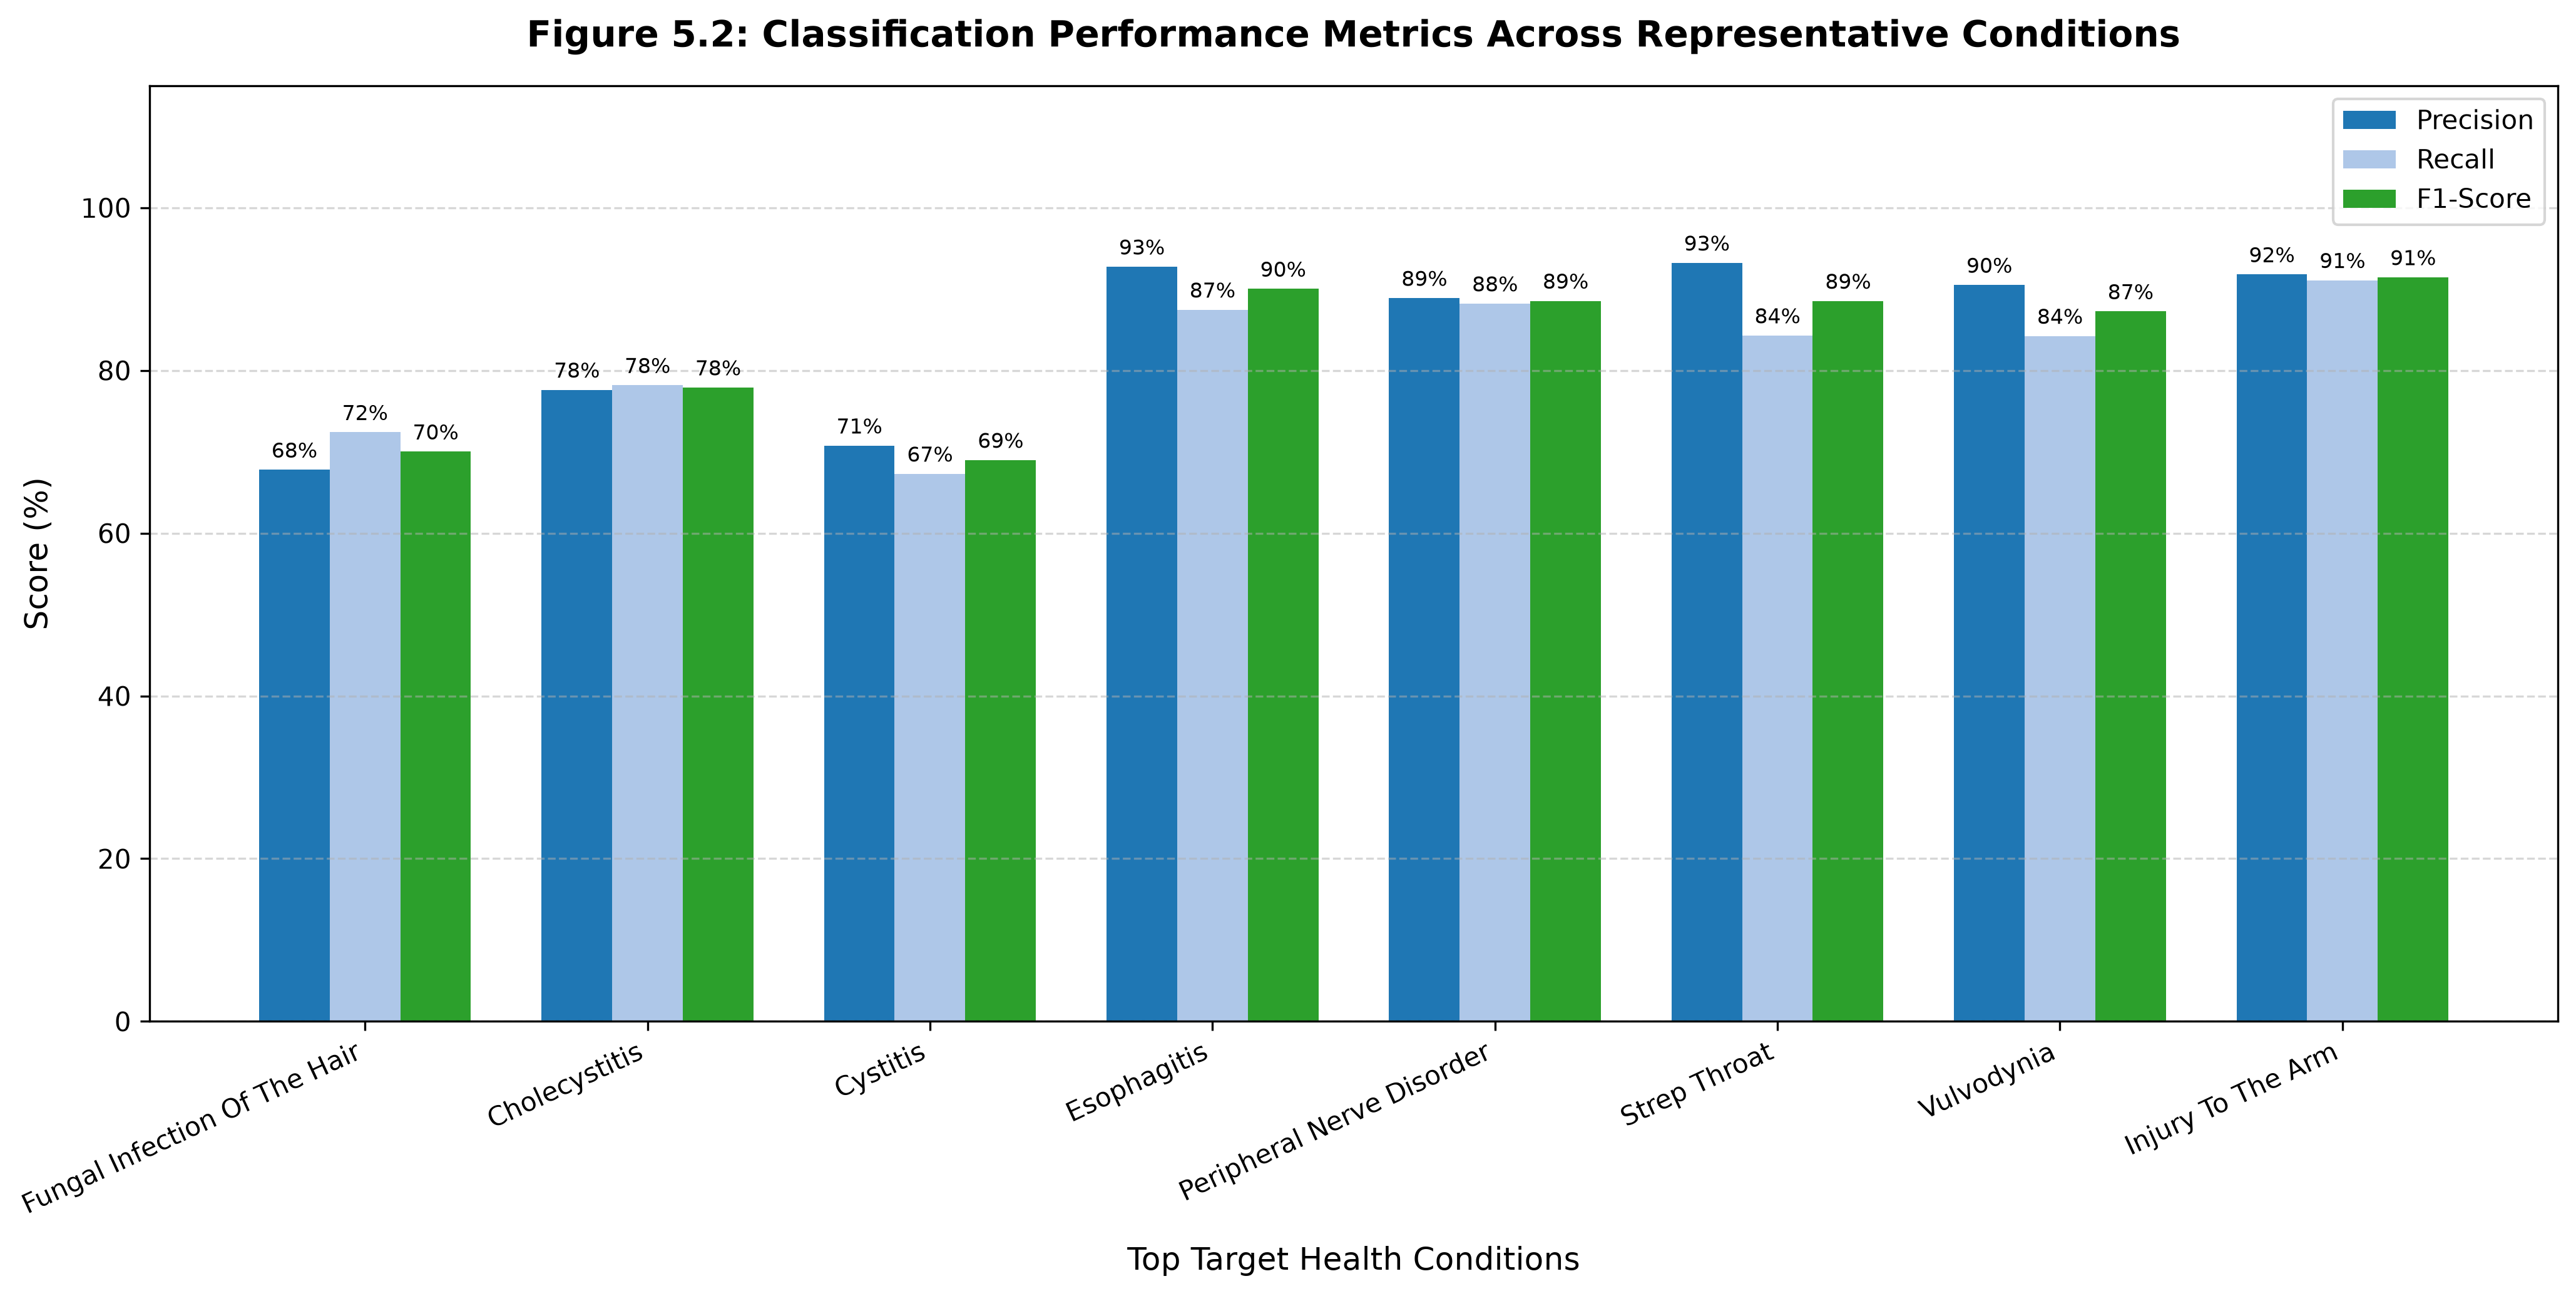

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/Final_Augmented_dataset_Diseases_and_Symptoms.csv')
X = df.drop(columns=['diseases'])
y = df['diseases']

_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = joblib.load('../models/symptom_checker_model.pkl')

y_pred = model.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)

classes = [k for k in report.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']]
top_classes = sorted(classes, key=lambda c: report[c]['support'], reverse=True)[:8]

precisions = [report[c]['precision'] * 100 for c in top_classes]
recalls = [report[c]['recall'] * 100 for c in top_classes]
f1_scores = [report[c]['f1-score'] * 100 for c in top_classes]

clean_labels = [c.replace('_', ' ').title() for c in top_classes]

x = np.arange(len(clean_labels))
width = 0.25

plt.figure(figsize=(14, 7), dpi=300)
plt.bar(x - width, precisions, width, label='Precision', color='#1f77b4')
plt.bar(x, recalls, width, label='Recall', color='#aec7e8')
plt.bar(x + width, f1_scores, width, label='F1-Score', color='#2ca02c')

plt.xlabel('Top Target Health Conditions', fontsize=12, labelpad=10)
plt.ylabel('Score (%)', fontsize=12, labelpad=10)
plt.title('Figure 5.2: Classification Performance Metrics Across Representative Conditions', fontsize=14, pad=15, fontweight='bold')
plt.xticks(x, clean_labels, rotation=25, ha='right', fontsize=10)
plt.ylim(0, 115)
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i in range(len(clean_labels)):
    plt.text(x[i] - width, precisions[i] + 1.5, f"{precisions[i]:.0f}%", ha='center', fontsize=8)
    plt.text(x[i], recalls[i] + 1.5, f"{recalls[i]:.0f}%", ha='center', fontsize=8)
    plt.text(x[i] + width, f1_scores[i] + 1.5, f"{f1_scores[i]:.0f}%", ha='center', fontsize=8)

plt.tight_layout()

plt.savefig('../docs/figure_5_2_metrics_chart.png', dpi=300, bbox_inches='tight')
plt.show()